# H2 consumption processing

Step-by-step pipeline for hydrogen-consumption experiments (biotic vs. sterile control).

**Flow:** load -> convert units -> trim startup -> subtract sterile control -> fit -> diagnostics
-> **rates (fully shown on one graph)** -> uncertainty.

**You choose the model** (`MODEL` in config). Both sigmoid and polynomial are fitted and shown so you
can compare, but the choice is yours.

**Active phase** is defined as 5% to 95% of total consumption (adjustable). The active-phase
**rate is the secant** (straight line) between those two boundary points, drawn on the graph so the
number is visibly the slope of the line you see. This matches the `(y2-y1)/(x2-x1)` calculation in
your original notebook.

Run top to bottom.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
try:
    from IPython.display import display
except Exception:
    display = print
rng = np.random.default_rng(0)

## 0. Configuration
Edit only this cell between experiments.

In [ ]:
# ---- paths ----
BASE = ""
PREFIX = "2026-04-02_h2-200bar_SRB"
PATH_TIME = f"{BASE}/{PREFIX}-time.npy"
PATH_VOL1 = f"{BASE}/{PREFIX}-volume_1.npy"   # biotic
PATH_VOL2 = f"{BASE}/{PREFIX}-volume_2.npy"   # sterile

# ---- gas / unit conversion (https://hydrogendensitycalculator.com/) ----
DENSITY    = 14.14    # kg/m^3
MOLAR_MASS = 2.016    # g/mol
# vol(ml)*DENSITY/MOLAR_MASS -> mmol (unit factors 1e-6, 1e3, 1e3 cancel)

# ---- geometry / normalisation ----
VOL_NORM    = 67.5    # ml, volume to normalise total consumption by
VOL_NORM_SD = 2.0     # ml, 1-sigma (sampling + handling); 0 disables
DIAMETER    = 4.5     # cm

# ---- YOUR CHOICES ----
MODEL        = "poly"   # "sigmoid" or "poly" -- YOU decide, no auto-selection
POLY_DEGREE  = 9
ACTIVE_LO, ACTIVE_HI = 0.05, 0.80  # active phase = this fraction of total consumption
TRIM_START_IX = None       # None = auto (argmin of biotic); or an int index
N_MC         = 4000

# ---- initial H2 injection ----
V_INJECT     = 20.0    # ml of H2 injected
V_INJECT_SD  = 1.0     # ml, 1-sigma
INJECT_BASIS = "experiment"  # "experiment": 20 ml is expressed AT experiment pressure -> uses DENSITY
                             # "injection":  20 ml is measured at the 100 bar injection P -> uses DENSITY_INJECT
DENSITY_INJECT = None  # kg/m^3, H2 density at 100 bar & experiment T (cmb.tech).
                       # Needed only for INJECT_BASIS="injection", or to report the volume at 100 bar.

AREA = np.pi * (DIAMETER / 2) ** 2
print(f"Model: {MODEL} | active phase: {ACTIVE_LO:.0%}-{ACTIVE_HI:.0%} | area: {AREA:.3f} cm^2")

Model: poly | active phase: 5%-80% | area: 15.904 cm^2


## 1. Load and inspect

In [42]:
time_min = np.load(PATH_TIME)
volume_1 = np.load(PATH_VOL1)
volume_2 = np.load(PATH_VOL2)
for n, a in [("time", time_min), ("volume_1", volume_1), ("volume_2", volume_2)]:
    print(f"{n:9s} len={len(a):6d} NaN={np.isnan(a).any()} inf={np.isinf(a).any()}")
assert len(time_min) == len(volume_1) == len(volume_2)
print("OK")

time      len= 38813 NaN=False inf=False
volume_1  len= 38813 NaN=False inf=False
volume_2  len= 38813 NaN=False inf=False
OK


In [43]:
def cut_last(n, *arrays):
    """Drop the last n datapoints from each array. Returns them in the same order.
    n=0 returns the arrays unchanged."""
    if n == 0:
        return arrays if len(arrays) > 1 else arrays[0]
    cut = [a[:-n] for a in arrays]
    return cut if len(cut) > 1 else cut[0]

time_min, volume_1, volume_2 = cut_last(100, time_min, volume_1, volume_2)

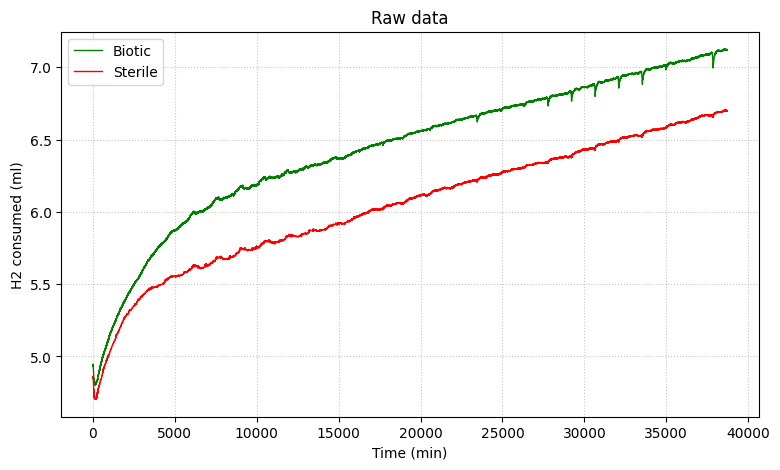

In [44]:
plt.figure(figsize=(9, 5))
plt.plot(time_min, volume_1, label="Biotic", color="green", lw=1)
plt.plot(time_min, volume_2, label="Sterile", color="red", lw=1)
plt.xlabel("Time (min)"); plt.ylabel("H2 consumed (ml)")
plt.title("Raw data"); plt.legend(); plt.grid(True, ls=":", alpha=0.7); plt.show()

## 2. Convert to days and mmol

In [45]:
def convert(time_array, v1, v2, density, molar_mass):
    return time_array /1440.0, v1 * density / molar_mass, v2 * density / molar_mass
time_days, moles_1, moles_2 = convert(time_min, volume_1, volume_2, DENSITY, MOLAR_MASS)
print(f"factor {DENSITY/MOLAR_MASS:.4f} mmol/ml, duration {time_days[-1]:.2f} d")

factor 7.0139 mmol/ml, duration 26.88 d


## 3. Trim startup, zero both axes
Cut everything before the start point (default = minimum of biotic curve), then shift so time **and**
both volume curves start at **0**. Override the cut with `TRIM_START_IX` if it lands wrong.

cut index 139 (t=0.10 d original), 38574 points kept
start point after zeroing: t=0.000 d, biotic=0.000, sterile=0.000 mmol


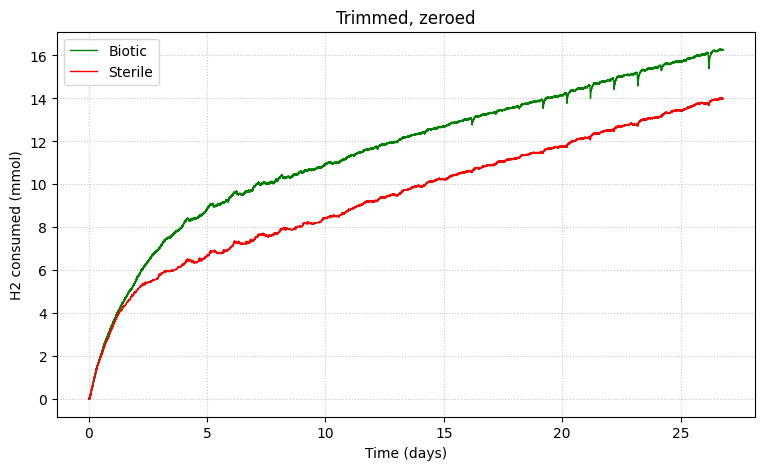

In [46]:
def trim_and_zero(td, mb, ms, start_ix=None):
    """Trim everything before the cut, then shift so time AND both volumes start at 0."""
    if start_ix is None:
        start_ix = int(np.nanargmin(mb))
    t  = td[start_ix:] - td[start_ix]          # time starts at 0
    mb = mb[start_ix:] - mb[start_ix]          # biotic starts at 0
    ms = ms[start_ix:] - ms[start_ix]          # sterile starts at 0
    return t, mb, ms, start_ix
t, moles_1_tr, moles_2_tr, cut_ix = trim_and_zero(time_days, moles_1, moles_2, TRIM_START_IX)
print(f"cut index {cut_ix} (t={time_days[cut_ix]:.2f} d original), {len(t)} points kept")
print(f"start point after zeroing: t={t[0]:.3f} d, biotic={moles_1_tr[0]:.3f}, sterile={moles_2_tr[0]:.3f} mmol")

plt.figure(figsize=(9, 5))
plt.plot(t, moles_1_tr, label="Biotic", color="green", lw=1)
plt.plot(t, moles_2_tr, label="Sterile", color="red", lw=1)
plt.xlabel("Time (days)"); plt.ylabel("H2 consumed (mmol)")
plt.title("Trimmed, zeroed"); plt.legend(); plt.grid(True, ls=":", alpha=0.7); plt.show()

## 4. Microbial consumption (biotic - sterile)

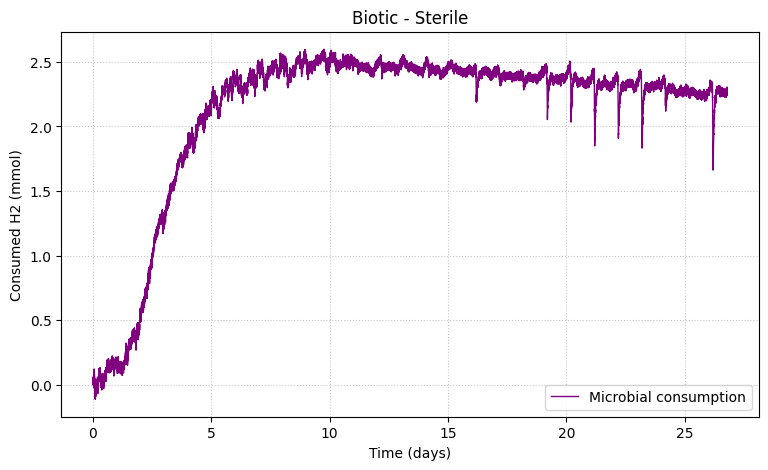

In [47]:
consumed = (moles_1_tr - moles_2_tr)
consumed = consumed - consumed[0]
assert not np.isnan(consumed).any() and not np.isinf(consumed).any()
plt.figure(figsize=(9, 5))
plt.plot(t, consumed, color="purple", lw=1, label="Microbial consumption")
plt.xlabel("Time (days)"); plt.ylabel("Consumed H2 (mmol)")
plt.title("Biotic - Sterile"); plt.legend(); plt.grid(True, ls=":", alpha=0.7); plt.show()

## 5. Fit both models (you choose which to use via `MODEL`)
Both are fitted and shown for comparison. The one named in `MODEL` is used downstream.
`curve_fit` uses scaled covariance, so parameter errors reflect the data scatter.

sigmoid: {'r2': np.float64(0.9791), 'adj_r2': np.float64(0.97909), 'rmse': np.float64(0.09247)}
poly9: {'r2': np.float64(0.99082), 'adj_r2': np.float64(0.99082), 'rmse': np.float64(0.06127)}

--> YOU chose: poly


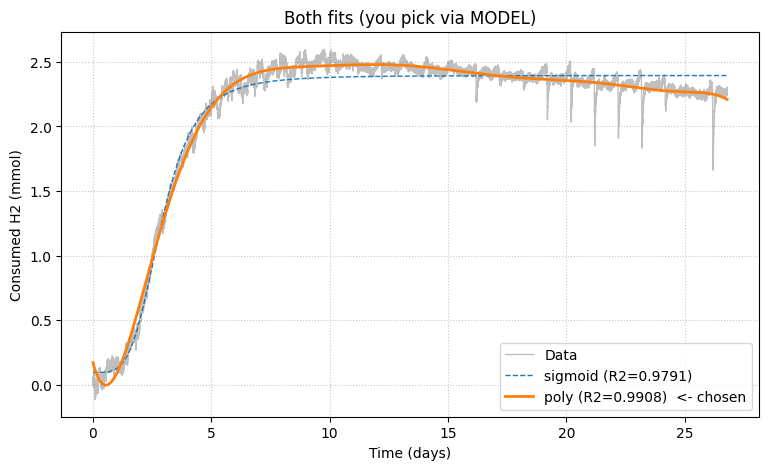

In [48]:
def sigmoid_4pl(x, A, D, C, B):
    return D + (A - D) / (1.0 + (x / C) ** B)

def gof(y, yhat, k):
    r = y - yhat; ss = np.sum(r**2); n = len(y)
    r2 = 1 - ss / np.sum((y - y.mean())**2)
    return dict(r2=r2, adj_r2=1-(1-r2)*(n-1)/(n-k-1), rmse=np.sqrt(ss/n))

fits = {}
try:
    p0 = [consumed.min(), consumed.max(), np.median(t), 2.0]
    bnd = ([-np.inf,-np.inf,1e-9,1e-6], [np.inf,np.inf,np.inf,np.inf])
    ps, cs = curve_fit(sigmoid_4pl, t, consumed, p0=p0, bounds=bnd, maxfev=20000)
    fits["sigmoid"] = dict(params=ps, cov=cs, k=4,
                           predict=lambda x, p: sigmoid_4pl(x, *p),
                           gof=gof(consumed, sigmoid_4pl(t, *ps), 4))
    print("sigmoid:", {k: round(v,5) for k,v in fits["sigmoid"]["gof"].items()})
except Exception as e:
    print("sigmoid failed:", e)

cp, covp = np.polyfit(t, consumed, POLY_DEGREE, cov=True)
fits["poly"] = dict(params=cp, cov=covp, k=POLY_DEGREE+1,
                    predict=lambda x, p: np.polyval(p, x),
                    gof=gof(consumed, np.polyval(cp, t), POLY_DEGREE+1))
print(f"poly{POLY_DEGREE}:", {k: round(v,5) for k,v in fits["poly"]["gof"].items()})

assert MODEL in fits, f"MODEL={MODEL} not available (sigmoid may have failed)"
chosen = fits[MODEL]
print(f"\n--> YOU chose: {MODEL}")

plt.figure(figsize=(9, 5))
plt.plot(t, consumed, color="gray", alpha=0.5, lw=1, label="Data")
for nm, f in fits.items():
    style = "-" if nm == MODEL else "--"
    lw = 2 if nm == MODEL else 1
    plt.plot(t, f["predict"](t, f["params"]), style, lw=lw,
             label=f"{nm} (R2={f['gof']['r2']:.4f}){'  <- chosen' if nm==MODEL else ''}")
plt.xlabel("Time (days)"); plt.ylabel("Consumed H2 (mmol)")
plt.title("Both fits (you pick via MODEL)"); plt.legend(); plt.grid(True, ls=":", alpha=0.7); plt.show()

## 6. Residual diagnostics (chosen model)

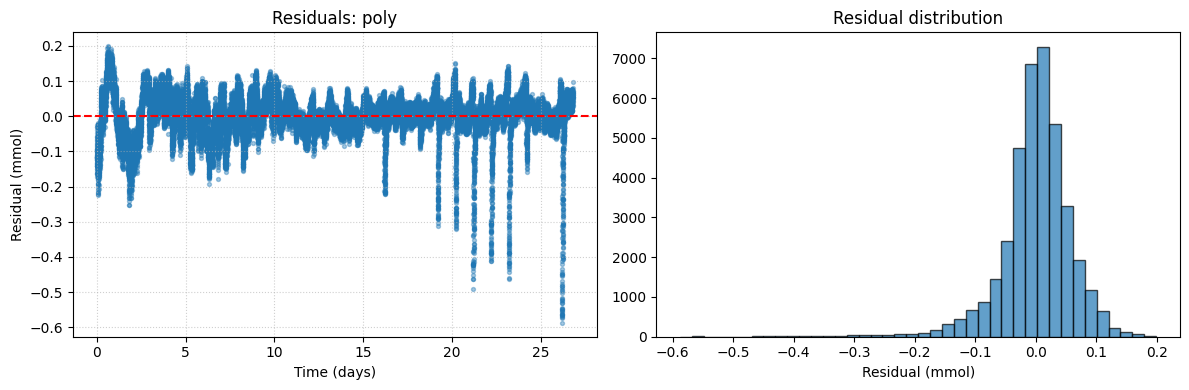

residual RMS 0.0613 mmol


In [49]:
resid = consumed - chosen["predict"](t, chosen["params"])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.scatter(t, resid, s=8, alpha=0.4); a1.axhline(0, color="red", ls="--")
a1.set_xlabel("Time (days)"); a1.set_ylabel("Residual (mmol)"); a1.set_title(f"Residuals: {MODEL}")
a1.grid(True, ls=":", alpha=0.6)
a2.hist(resid, bins=40, alpha=0.7, edgecolor="k"); a2.set_title("Residual distribution")
a2.set_xlabel("Residual (mmol)"); plt.tight_layout(); plt.show()
print(f"residual RMS {np.sqrt(np.mean(resid**2)):.4f} mmol")

## 7. Rates - everything shown on one graph

The consumption signal can **rise to a peak and then decline** (gas re-release / external effects
after total consumption is reached). The decline is not microbial consumption, so the **consumption
phase is defined as baseline -> peak of the fitted curve**, and total and rates use only that rising
segment. For a purely monotonic fit (e.g. a sigmoid that plateaus) the peak is the last point, so
this reduces to the usual behaviour.

All quantities are drawn so nothing is computed off-screen:
- **black curve**: the fitted model on a dense grid
- **purple star**: the **peak** = total consumed (max cumulative consumption)
- **green shaded band**: the **active phase**, 5% to 95% of the rise from baseline to peak
- **thick blue line**: the **secant** whose slope IS the reported active-phase rate
  (matching your `(y2-y1)/(x2-x1)`)
- **red segment + shaded day**: the **max rate** = the steepest single **1-day** window inside the
  active phase. The active phase is split into consecutive 1-day intervals, the slope of each is
  found by least-squares, and the largest is reported (all per-day slopes are printed).
- **right-hand vertical span**: the **total consumed H2** (peak - baseline)

Adjust the band with `ACTIVE_LO` / `ACTIVE_HI` in config.

In [51]:
def fitted_grid(model, n=2000):
    # Evaluate the FITTED model on a fixed-size grid. Purpose: (1) a smooth curve so
    # np.gradient isn't differentiating measurement noise, and (2) fixed cost for the
    # derivative/boundary/Monte-Carlo steps regardless of run length. (Raw data ~1-min spacing.)
    xg = np.linspace(t[0], t[-1], n)
    return xg, model["predict"](xg, model["params"])

# def peak_index(yg):
#     # Consumption phase is baseline -> PEAK of the fitted curve. After the peak the signal
#     # can decline (gas re-release / external effects) which is NOT microbial consumption,
#     # so total and rates use only the rising segment [0 .. peak].
#     return int(np.argmax(yg))

def percent_boundaries(xg, yg, i_peak, lo, hi):
    # Invert y->x on the RISING segment only, so each y maps to a single time
    # (np.interp requires an increasing y).
    i_peak = max(int(i_peak), 1)
    xs, ys = xg[:i_peak+1], yg[:i_peak+1]
    tot = ys[-1] - ys[0]
    if tot <= 0:
        return 0, i_peak
    tl = np.interp(ys[0] + lo*tot, ys, xs)
    th = np.interp(ys[0] + hi*tot, ys, xs)
    return int(np.argmin(np.abs(xg-tl))), int(np.argmin(np.abs(xg-th)))

def secant(xg, yg, i, j):
    return (yg[j] - yg[i]) / (xg[j] - xg[i])

def daily_rates(xg, yg, t_start, t_end):
    # Split [t_start, t_end] into consecutive 1-day windows; least-squares slope of each.
    # Returns list of (day_start, day_end, slope_mmol_per_day).
    edges = np.arange(np.floor(t_start), np.ceil(t_end) + 1)
    rows = []
    for d0, d1 in zip(edges[:-1], edges[1:]):
        m = (xg >= d0) & (xg < d1)
        if m.sum() >= 2:
            rows.append((d0, d1, float(np.polyfit(xg[m], yg[m], 1)[0])))
    return rows

def peak_index(xg, yg):
    # Consumption phase is baseline -> PEAK of the fitted curve. After the peak the signal
    # can decline (gas re-release / external effects) which is NOT microbial consumption,
    # so total and rates use only the rising segment [0 .. peak].
    # Ignore the last day when locating the peak (avoids a late-time artifact being picked).
    cutoff = xg[-1] - 1  # one day before the end (xg is in days)
    valid = xg <= cutoff
    return int(np.argmax(np.where(valid, yg, -np.inf)))

xg, yg = fitted_grid(chosen)
i_peak = peak_index(xg, yg)
assert i_peak >= 1, "Fitted curve peaks at t=0; no rising phase to analyse."

i_lo, i_hi = percent_boundaries(xg, yg, i_peak, ACTIVE_LO, ACTIVE_HI)
active_rate = secant(xg, yg, i_lo, i_hi)

# max rate = largest per-day slope within the active phase
days = daily_rates(xg, yg, xg[i_lo], xg[i_hi])
assert days, "active phase shorter than one day-window; widen ACTIVE_LO/HI or check the fit"
max_day = max(days, key=lambda r: r[2])
max_rate = max_day[2]

# total consumed = PEAK minus baseline (max cumulative consumption, before any decline)
total = yg[i_peak] - yg[0]
declined = yg[-1] < yg[i_peak] - 1e-9

print(f"Peak consumption at t={xg[i_peak]:.2f} d")
if declined:
    print(f"  curve declines after peak by {yg[i_peak]-yg[-1]:.4f} mmol (excluded from total/rates)")
print(f"Per-day slopes in active phase:")
for d0, d1, s in days:
    star = "  <-- MAX" if s == max_rate else ""
    print(f"    day [{d0:.0f},{d1:.0f}): {s:.4f} mmol/day{star}")
print(f"Max rate:            {max_rate:.4f} mmol/day  (day [{max_day[0]:.0f},{max_day[1]:.0f}))")
print(f"Active-phase rate:   {active_rate:.4f} mmol/day  window [{xg[i_lo]:.2f},{xg[i_hi]:.2f}] d")
print(f"Total consumed:      {total:.4f} mmol  (peak - baseline)")

Peak consumption at t=11.89 d
  curve declines after peak by 0.2704 mmol (excluded from total/rates)
Per-day slopes in active phase:
    day [1,2): 0.5614 mmol/day
    day [2,3): 0.6522 mmol/day  <-- MAX
    day [3,4): 0.5211 mmol/day
    day [4,5): 0.3382 mmol/day
Max rate:            0.6522 mmol/day  (day [2,3))
Active-phase rate:   0.5537 mmol/day  window [1.43,4.56] d
Total consumed:      2.3071 mmol  (peak - baseline)


In [52]:
def time_to_fraction(xg, yg, frac):
    """Time from the start (xg[0]) until the fitted curve first reaches `frac` of the
    total rise (baseline -> peak). Uses the rising segment only, so it stays valid even
    when the curve declines after the peak. Returns days (xg is in days)."""
    i_peak = int(np.argmax(yg))
    xs, ys = xg[:i_peak+1], yg[:i_peak+1]
    tot = ys[-1] - ys[0]
    if tot <= 0:
        return np.nan
    return float(np.interp(ys[0] + frac*tot, ys, xs) - xg[0])

def time_to_90pct(xg, yg):
    """Time from start until 90% of total consumption."""
    return time_to_fraction(xg, yg, 0.90)

def time_to_5pct(xg, yg):
    """Time from start until 5% of total consumption (a lag-time measure)."""
    return time_to_fraction(xg, yg, 0.05)

In [53]:
print(f"Time to  5% change: {time_to_5pct(xg, yg):.3f} days")
print(f"Time to 90% change: {time_to_90pct(xg, yg):.3f} days")

Time to  5% change: 1.428 days
Time to 90% change: 5.453 days


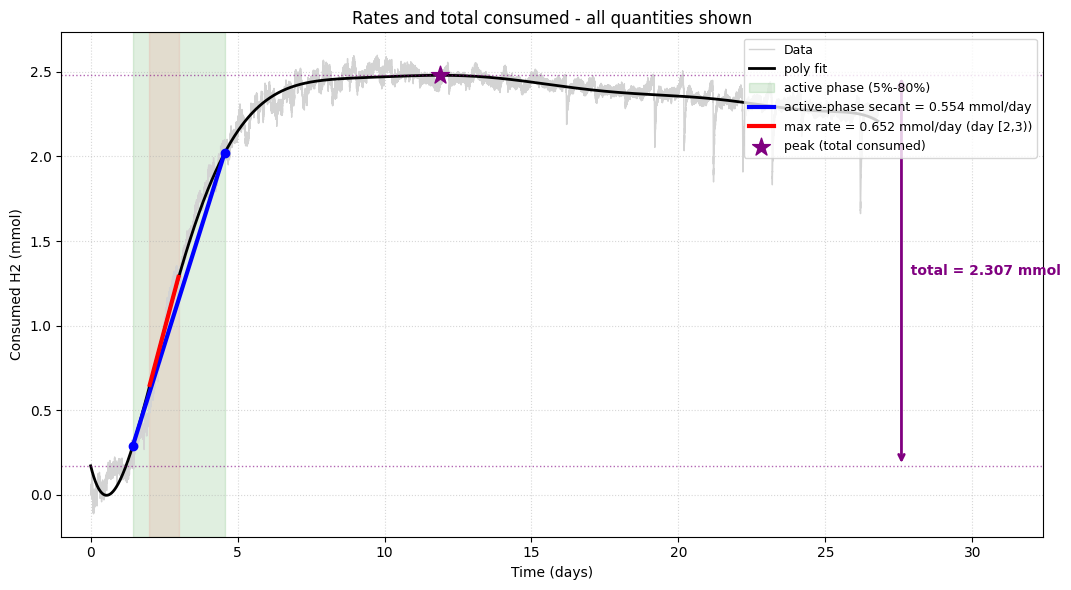

In [55]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(t, consumed, color="lightgray", lw=1, label="Data")
ax.plot(xg, yg, color="black", lw=2, label=f"{MODEL} fit")

# active-phase band (5-95%)
ax.axvspan(xg[i_lo], xg[i_hi], color="green", alpha=0.12,
           label=f"active phase ({ACTIVE_LO:.0%}-{ACTIVE_HI:.0%})")

# secant = reported active rate
ax.plot([xg[i_lo], xg[i_hi]], [yg[i_lo], yg[i_hi]], color="blue", lw=3,
        label=f"active-phase secant = {active_rate:.3f} mmol/day")
ax.scatter([xg[i_lo], xg[i_hi]], [yg[i_lo], yg[i_hi]], color="blue", zorder=5)

# max rate = steepest 1-day window: draw that day's slope line
md0, md1 = max_day[0], max_day[1]
mmask = (xg >= md0) & (xg < md1)
mx = xg[mmask]
my = np.polyval(np.polyfit(mx, yg[mmask], 1), mx)
ax.plot(mx, my, color="red", lw=3,
        label=f"max rate = {max_rate:.3f} mmol/day (day [{md0:.0f},{md1:.0f}))")
ax.axvspan(md0, md1, color="red", alpha=0.08)

# peak = total consumed
y_peak = yg[i_peak]
ax.scatter([xg[i_peak]], [y_peak], color="purple", marker="*", s=180, zorder=7,
           label="peak (total consumed)")

# total consumed interval (right side, vertical arrows): baseline -> PEAK
x_arrow = xg[-1] + (xg[-1]-xg[0])*0.03
ax.annotate("", xy=(x_arrow, y_peak), xytext=(x_arrow, yg[0]),
            arrowprops=dict(arrowstyle="<->", color="purple", lw=2))
ax.text(x_arrow, (yg[0]+y_peak)/2, f"  total = {total:.3f} mmol",
        color="purple", va="center", fontweight="bold")
ax.axhline(yg[0], color="purple", ls=":", lw=1, alpha=0.6)
ax.axhline(y_peak, color="purple", ls=":", lw=1, alpha=0.6)

ax.set_xlabel("Time (days)"); ax.set_ylabel("Consumed H2 (mmol)")
ax.set_title("Rates and total consumed - all quantities shown")
ax.legend(loc="upper right", fontsize=9); ax.grid(True, ls=":", alpha=0.5)
ax.set_xlim(-1, x_arrow + (xg[-1]-xg[0])*0.18)
plt.tight_layout(); plt.show()

## 8. Uncertainty (Monte Carlo)
Combines fit-parameter scatter (from covariance) and `VOL_NORM = 67.5 +/- 2 ml`. Each draw recomputes
every quantity using the **same** functions and active-phase window as the graph above.

In [14]:
draws = rng.multivariate_normal(chosen["params"], chosen["cov"], size=N_MC)
vols = rng.normal(VOL_NORM, VOL_NORM_SD, size=N_MC)
out = {"total": [], "max_rate": [], "active_rate": []}
for p, V in zip(draws, vols):
    yy = chosen["predict"](xg, p)
    ip = peak_index(xg, yy)
    a, b = percent_boundaries(xg, yy, ip, ACTIVE_LO, ACTIVE_HI)
    dr = daily_rates(xg, yy, xg[a], xg[b])
    mr = max(r[2] for r in dr) if dr else np.nan
    ar = secant(xg, yy, a, b); tot = yy[ip] - yy[0]
    out["total"].append(tot); out["max_rate"].append(mr); out["active_rate"].append(ar)

T  = np.array(out["total"])        # total consumed (mmol)
MR = np.array(out["max_rate"])     # max per-day rate (mmol/day)
AR = np.array(out["active_rate"])  # active-phase / "total" rate (mmol/day)
Vm3  = vols           # ml 
gfac = MOLAR_MASS / 1000.0         # mmol -> g  (1 mmol H2 = MOLAR_MASS/1000 g)

rows = [
    ("total consumed H2 (mmol)",     T),
    ("total consumed H2 (mmol/ml)",  T / vols),
    ("max rate (mmol/day)",          MR),
    ("max rate (mmol/day/cm^2)",     MR / AREA),
    ("total rate (mmol/day)",        AR),
    ("total rate (mmol/day/cm^2)",   AR / AREA),
    ("total rate (g/day)",           AR * gfac),
    ("max rate (g/day)",             MR * gfac),
    ("max rate (mmol/day/mL)",      MR / Vm3),
]
def vpm(s):
    return f"{np.median(s):.4g} \u00b1 {np.std(s):.4g}"
summary = pd.DataFrame(
    [(name, vpm(s)) for name, s in rows],
    columns=["quantity", "value \u00b1 1\u03c3"]
).set_index("quantity")
display(summary)

,value ± 1σ
quantity,
total consumed H2 (mmol),2.298 ± 0.002199
total consumed H2 (mmol/ml),0.03404 ± 0.001002
max rate (mmol/day),0.8341 ± 0.001829
max rate (mmol/day/cm^2),0.05245 ± 0.000115
total rate (mmol/day),0.6488 ± 0.00169
total rate (mmol/day/cm^2),0.04079 ± 0.0001062
total rate (g/day),0.001308 ± 3.407e-06
max rate (g/day),0.001682 ± 3.687e-06
max rate (mmol/day/mL),0.01236 ± 0.0003642


## 9. Initial H2 injected and fraction consumed

Moles injected = `V_inject * density / molar_mass`. Because **moles are conserved during
pressurization**, injecting at 100 bar and then raising to experiment pressure does not change the
injected amount - only the density used to express the volume matters.

`INJECT_BASIS`:
- `"experiment"` (default): the 20 ml is expressed **at experiment pressure**, so it uses the same
  `DENSITY` as the consumption conversion. The fraction consumed is then a clean volume ratio
  (density cancels).
- `"injection"`: the 20 ml is the volume **measured at the 100 bar injection pressure**; set
  `DENSITY_INJECT` (H2 density at 100 bar and experiment T, from cmb.tech).

The +/-1 ml injection uncertainty is propagated; the fraction consumed combines it with the
consumption uncertainty from step 8 (the two are independent).

In [15]:
if INJECT_BASIS == "experiment":
    rho_inj = DENSITY
elif INJECT_BASIS == "injection":
    assert DENSITY_INJECT is not None, "set DENSITY_INJECT (H2 density at 100 bar, exp T)"
    rho_inj = DENSITY_INJECT
else:
    raise ValueError("INJECT_BASIS must be 'experiment' or 'injection'")

moles_injected    = V_INJECT    * rho_inj / MOLAR_MASS
moles_injected_sd = V_INJECT_SD * rho_inj / MOLAR_MASS   # density treated as exact
print(f"Injection basis: {INJECT_BASIS} (density {rho_inj:.3f} kg/m^3)")
print(f"H2 initially injected: {moles_injected:.4f} +/- {moles_injected_sd:.4f} mmol")

if DENSITY_INJECT is not None:
    V_at_100bar = moles_injected * MOLAR_MASS / DENSITY_INJECT
    print(f"...corresponds to {V_at_100bar:.2f} ml measured at the 100 bar injection pressure")

Injection basis: experiment (density 14.140 kg/m^3)
H2 initially injected: 140.2778 +/- 7.0139 mmol


Total consumed:    2.2978 mmol
Injected:          140.2778 +/- 7.0139 mmol
Fraction consumed: 1.64 +/- 0.08 %  (16-84%: 1.56-1.72 %)


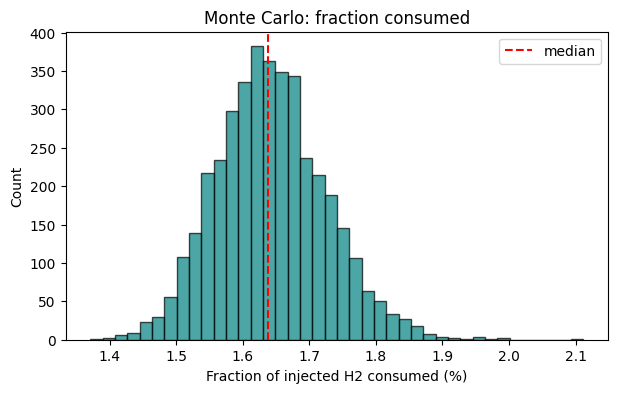

In [16]:
# fraction of injected H2 consumed (microbial), combining +/-1 ml injection with step-8 consumption MC
inj_draws = rng.normal(V_INJECT, V_INJECT_SD, size=N_MC) * rho_inj / MOLAR_MASS
total_draws = np.array(out["total"])
frac = total_draws / inj_draws
fm, fsd = np.median(frac), np.std(frac)
f16, f84 = np.percentile(frac, [16, 84])
tot_med = np.median(total_draws)
print(f"Total consumed:    {tot_med:.4f} mmol")
print(f"Injected:          {moles_injected:.4f} +/- {moles_injected_sd:.4f} mmol")
print(f"Fraction consumed: {fm*100:.2f} +/- {fsd*100:.2f} %  (16-84%: {f16*100:.2f}-{f84*100:.2f} %)")

plt.figure(figsize=(7, 4))
plt.hist(frac*100, bins=40, color="teal", alpha=0.7, edgecolor="k")
plt.axvline(fm*100, color="red", ls="--", label="median")
plt.xlabel("Fraction of injected H2 consumed (%)"); plt.ylabel("Count")
plt.title("Monte Carlo: fraction consumed"); plt.legend(); plt.show()

## 10. Reuse
Edit only the Configuration cell. Set `MODEL` to pick sigmoid or poly. Set `ACTIVE_LO` / `ACTIVE_HI`
to change the active-phase window. Set `V_INJECT` / `INJECT_BASIS` for the initial dose. Adjust
`TRIM_START_IX` if the auto cut point is wrong.